In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
from src_v1.utils import load_activation_data

In [4]:
weights_paths = "/Users/saru/Local_Work/neuromodul/fscv/tests_code/data_1d_vxlbl"
train_collapsed_per_electrode, test_collapsed_per_electrode, y_mean_collapsed_per_electrode, y_std_collapsed_per_electrode, mono_dom_list, test_probe_collapsed = load_activation_data(weights_paths,ret_np=True)
train_full, test_full, y_mean_full, y_std_full, _, test_probe_full = load_activation_data(weights_paths,test_probe=test_probe_collapsed,collapsed=False,ret_np=True)

Getting pairs collapsed.
First activation shape(35, 1000, 80)
First label shape(35, 4)
Expert activation set shape: (1068, 1000, 80)
Labels shape: (1068, 4)
First label row (all 4 cols): [0.  0.  0.  7.4]

Available probe IDs:
['AFOR__ALC_INM001_99bW02R01' 'AFOR__BFA_INM001_99bW06R09'
 'ALCIS_155__ALC_INM001_01b' 'ALCIS_155__ALC_INM001_02b'
 'ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'
 'ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'
 'ALCIS_240__ALC1_INM001_01bW03R01' 'ALCIS_240__ALC2_INM001_02bW03R01'
 'BFvsALC__ALC_INM001_99bW02R01' 'BFvsALC__BFA_INM001_99bW06R09'
 'alc__ALC_INM001_99bW02R01' 'bfa__BFA_INM001_99bW06R09']
No test_probe specified — randomly selected: AFOR__BFA_INM001_99bW06R09
Test probe:  AFOR__BFA_INM001_99bW06R09
Train probes: [np.str_('AFOR__ALC_INM001_99bW02R01'), np.str_('ALCIS_155__ALC_INM001_01b'), np.str_('ALCIS_155__ALC_INM001_02b'), np.str_('ALCIS_155_macroREF__ALC1_INM001_01bW04R01M'), np.str_('ALCIS_155_macroREF__ALC2_INM001_02bW02R01M'), np.str_('ALCIS_240_

In [13]:
T = train_full[0].shape[1]
def logreg_classifier(train, test):
    
    acc_over_t = []
    for t in range(T):
        X_train = train[0][:,t,:]
        X_test = test[0][:,t,:]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        reg = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
        reg.fit(X_train_s, train[1])

        acc_over_t.append(reg.score(X_test_s, test[1]))

    return acc_over_t
acc_over_t_collapsed_over_electrode = logreg_classifier(train_collapsed_per_electrode,test_collapsed_per_electrode)
acc_over_t_full = logreg_classifier(train_full,test_full)

In [18]:
import matplotlib.pyplot as plt
def logreg_classifier_mean(train, test):
    
    X_train = train[0].mean(axis=1)
    X_test = test[0].mean(axis=1)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    reg = LogisticRegression(max_iter=1000, C=1.0,class_weight='balanced')
    reg.fit(X_train_s, train[1])

    return reg.score(X_test_s, test[1])
acc_collapsed_mean = logreg_classifier_mean(train_collapsed_per_electrode,test_collapsed_per_electrode)
acc_full_mean = logreg_classifier_mean(train_full,test_full)

Text(0, 0.5, 'Accuracy')

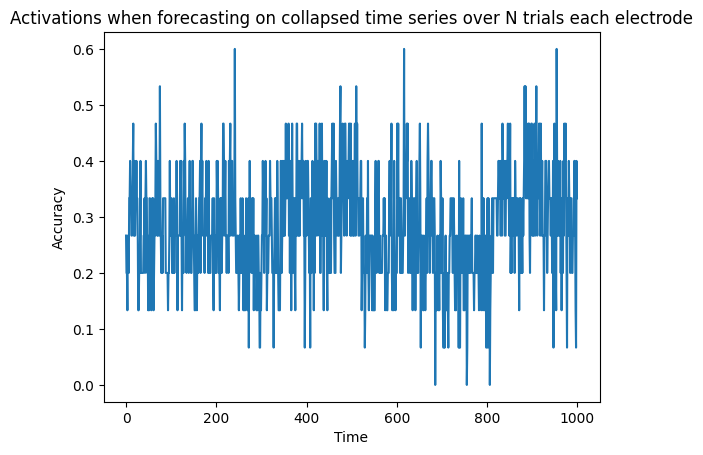

In [19]:


plt.plot(range(T), acc_over_t_collapsed_over_electrode)
plt.title("Activations when forecasting on collapsed time series over N trials each electrode")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

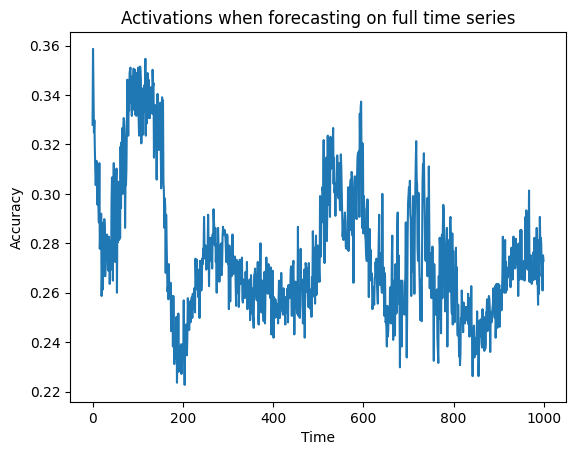

In [20]:
plt.plot(range(T), acc_over_t_full)
plt.title("Activations when forecasting on full time series")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [21]:
print("Acc with all sweeps with mean over time:",acc_full_mean)
print("Acc with mean over sweeps with mean over time:",acc_collapsed_mean)

Acc with all sweeps with mean over time: 0.288
Acc with mean over sweeps with mean over time: 0.13333333333333333


In [12]:
from collections import Counter
print("Test label distribution:", Counter(test_full[1]))
print("Train label distribution:", Counter(train_full[1]))

Test label distribution: Counter({np.int64(3): 900, np.int64(0): 450, np.int64(1): 450, np.int64(2): 450})
Train label distribution: Counter({np.int64(0): 4650, np.int64(3): 1650, np.int64(1): 600, np.int64(2): 600})


t_peak: 1
              precision    recall  f1-score   support

          DA       0.24      0.18      0.21       450
         5HT       0.13      0.05      0.07       450
          NE       0.28      0.14      0.19       450
          EQ       0.42      0.71      0.53       900

    accuracy                           0.36      2250
   macro avg       0.27      0.27      0.25      2250
weighted avg       0.30      0.36      0.31      2250



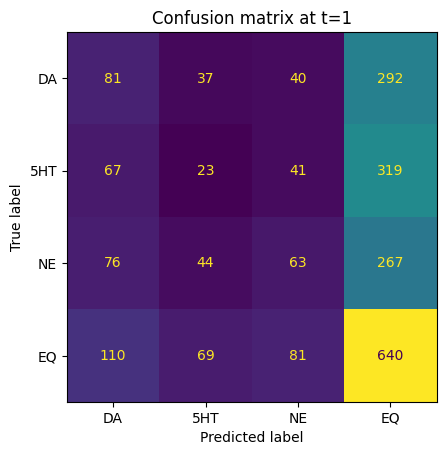

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
t_peak = np.argmax(acc_over_t_full)
print(f"t_peak: {t_peak}")
X_tpeak_tr = train_full[0][:,t_peak,:]
X_tpeak_test = test_full[0][:,t_peak,:]

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tpeak_tr)
X_te_s = scaler.transform(X_tpeak_test)

clf = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced')
clf.fit(X_tr_s, train_full[1])

y_pred = clf.predict(X_te_s)

print(classification_report(test_full[1], y_pred, target_names=['DA','5HT','NE','EQ']))

cm = confusion_matrix(test_full[1], y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['DA','5HT','NE','EQ'])
disp.plot(colorbar=False)
plt.title(f"Confusion matrix at t={t_peak}")
plt.show()

In [27]:
train, test, y_mean, y_std, mono_dom_list, test_probe = load_activation_data(
    weights_paths,
    collapsed=False,
    test_probe='BFvsALC__BFA_INM001_99bW06R09',
    ret_np=True)


Getting pairs not collapsed.
First activation shape(2250, 1000, 80)
First label shape(2250, 4)
Expert activation set shape: (9750, 1000, 80)
Labels shape: (9750, 4)
First label row (all 4 cols): [0.  0.  0.  7.4]

Available probe IDs:
['AFOR__ALC_INM001_99bW02R01' 'AFOR__BFA_INM001_99bW06R09'
 'ALCIS_155__ALC_INM001_01b']


AssertionError: test_probe 'BFvsALC__BFA_INM001_99bW06R09' not found. Available: ['AFOR__ALC_INM001_99bW02R01' 'AFOR__BFA_INM001_99bW06R09'
 'ALCIS_155__ALC_INM001_01b']

# Below is the non-probe based split results, do not change

Text(0, 0.5, 'Accuracy')

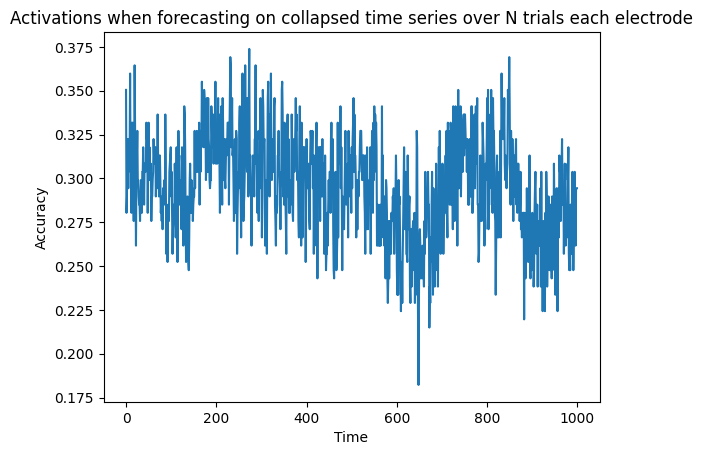

In [ ]:


plt.plot(range(T), acc_over_t_collapsed_over_electrode)
plt.title("Activations when forecasting on collapsed time series over N trials each electrode")
plt.xlabel("Time")
plt.ylabel("Accuracy")

Text(0, 0.5, 'Accuracy')

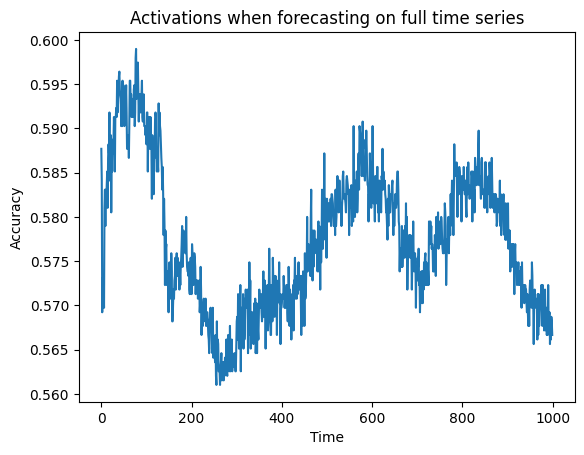

In [28]:
plt.plot(range(T), acc_over_t_full)
plt.title("Activations when forecasting on full time series")
plt.xlabel("Time")
plt.ylabel("Accuracy")

In [ ]:
print(acc_full_mean)
print(acc_collapsed_mean)

0.5948717948717949
0.308411214953271
